# Regression Track — Crop Yield Dataset


## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn import set_config

sns.set_style("whitegrid")
sns.set_palette("colorblind")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", None)
set_config(display="text")  # keep estimator output as plain text, not the HTML diagram widget

### Section A — Dataset & EDA
### A1. Dataset Loading & Audit

In [2]:
df = pd.read_csv("Crop Yeild Data.csv")
df.columns = df.columns.str.strip()

# Clean stray whitespace inside string columns (e.g. 'Kharif     ' -> 'Kharif')
for c in df.select_dtypes(include="object").columns:
    df[c] = df[c].str.strip()

df

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield,Avg_Temperature,Max_Temperature,Min_Temperature
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796,23.692,33.435,14.779
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710,23.692,33.435,14.779
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238,23.692,33.435,14.779
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.052,23.692,33.435,14.779
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.421,23.692,33.435,14.779
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19684,Small millets,1998,Kharif,Nagaland,4000.0,2000,1498.0,395200.00,1160.00,0.500,20.292,29.860,12.067
19685,Wheat,1998,Rabi,Nagaland,1000.0,3000,1498.0,98800.00,290.00,3.000,20.292,29.860,12.067
19686,Maize,1997,Kharif,Jammu and Kashmir,310883.0,440900,1356.2,29586735.11,96373.73,1.285,-3.143,9.582,-15.017
19687,Rice,1997,Kharif,Jammu and Kashmir,275746.0,5488,1356.2,26242746.82,85481.26,0.017,-3.143,9.582,-15.017


In [3]:
print("Shape:", df.shape)

print("\n=== Data types ===")
print(df.dtypes)

print("\n=== Missing value counts ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
print(missing_summary[missing_summary["Missing Count"] > 0].sort_values("Missing %", ascending=False))
if missing.sum() == 0:
    print("(no missing values in any column)")

print("\n=== Target (Yield) distribution ===")
print(df["Yield"].describe())

print("\n=== Season value counts ===")
print(df["Season"].value_counts())

print("\n=== Crop / State cardinality ===")
print("Unique Crops:", df["Crop"].nunique())
print("Unique States:", df["State"].nunique())

Shape: (19689, 13)

=== Data types ===
Crop                object
Crop_Year            int64
Season              object
State               object
Area               float64
Production           int64
Annual_Rainfall    float64
Fertilizer         float64
Pesticide          float64
Yield              float64
Avg_Temperature    float64
Max_Temperature    float64
Min_Temperature    float64
dtype: object

=== Missing value counts ===
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []
(no missing values in any column)

=== Target (Yield) distribution ===
count    19689.000000
mean        79.954011
std        878.306194
min          0.000000
25%          0.600000
50%          1.030000
75%          2.389000
max      21105.000000
Name: Yield, dtype: float64

=== Season value counts ===
Season
Kharif        8232
Rabi          5742
Whole Year    3717
Summer        1195
Autumn         414
Winter         389
Name: count, dtype: int64

=== Crop / State cardinality ===
Unique Crops: 55
Un

### A2. EDA Visualisations

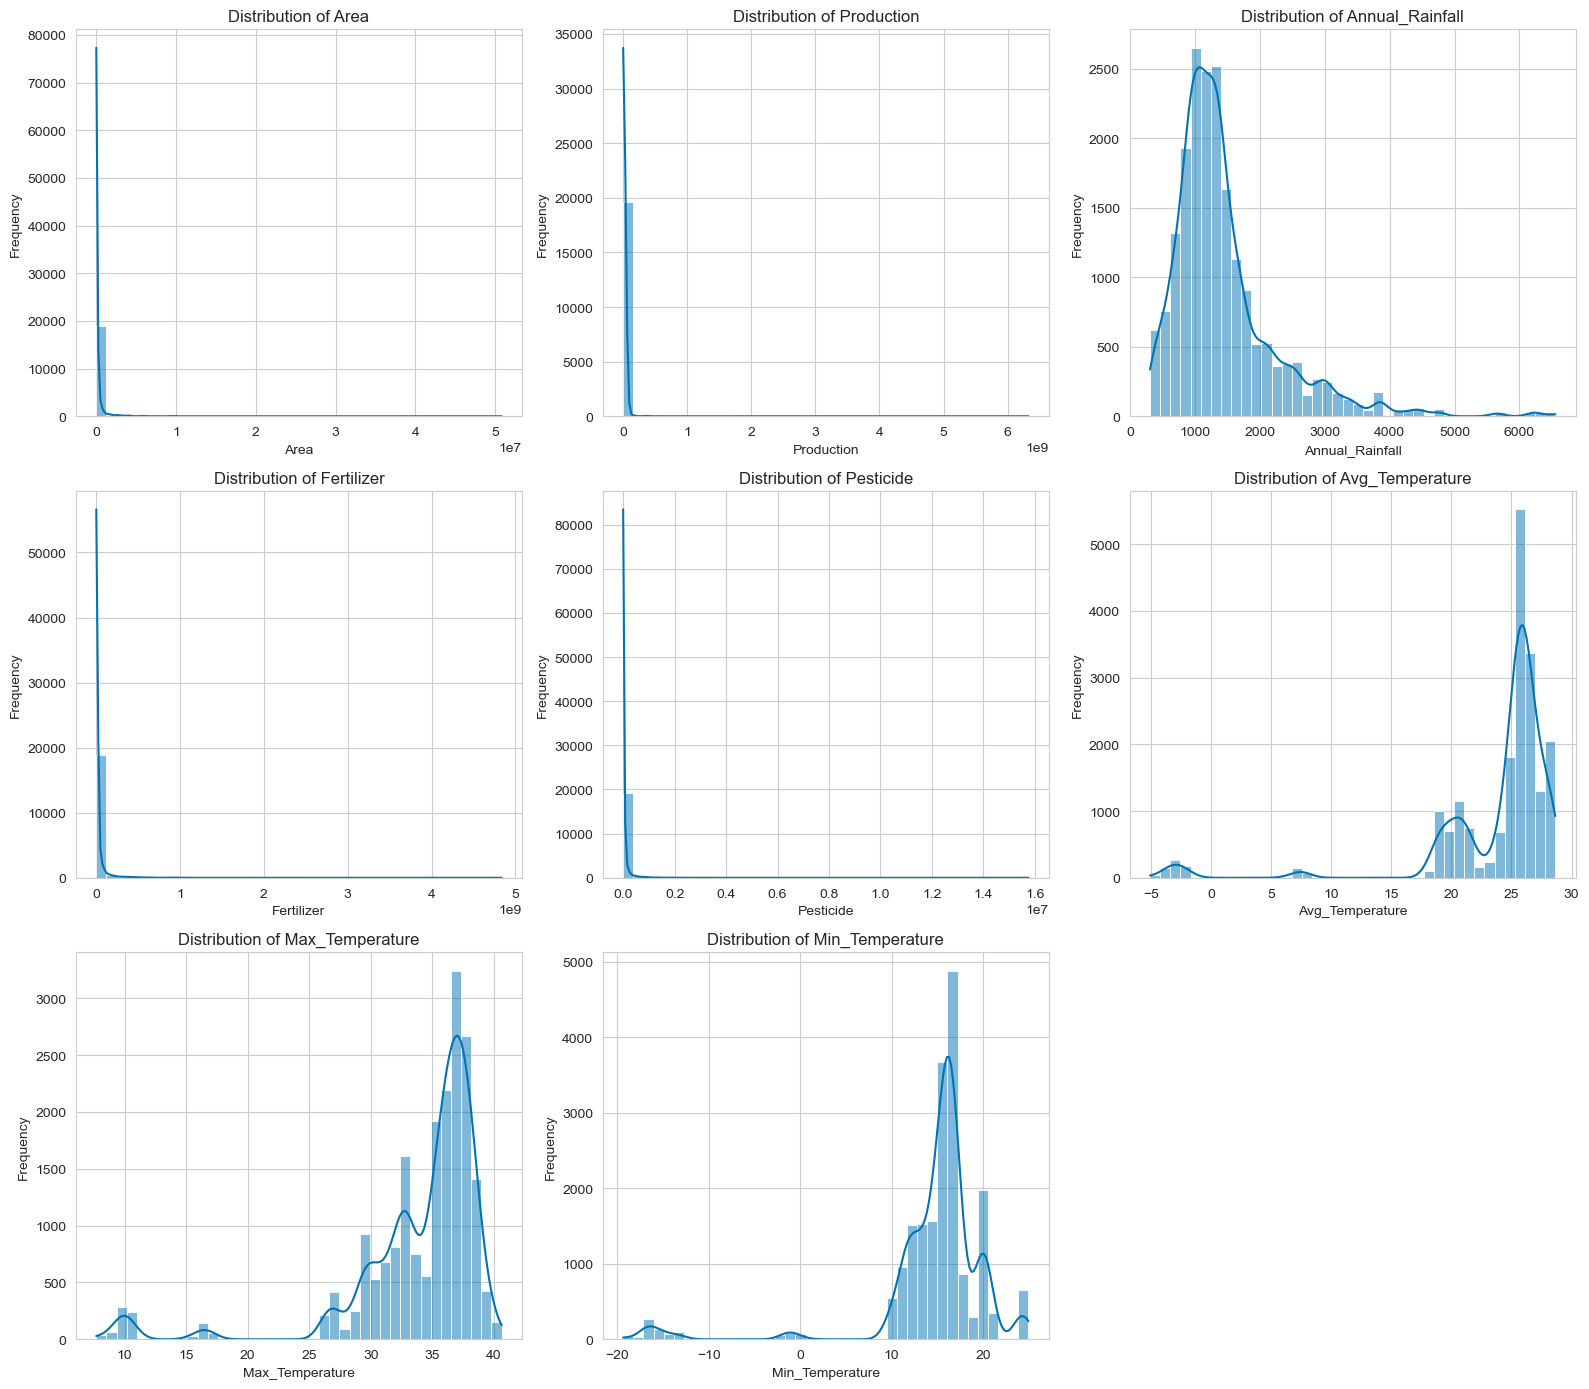

In [4]:
numeric_cols = ["Area", "Production", "Annual_Rainfall", "Fertilizer", "Pesticide",
                "Avg_Temperature", "Max_Temperature", "Min_Temperature"]

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax, bins=40)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
axes.flatten()[-1].axis("off")
plt.tight_layout()
plt.savefig("feature_distributions.png", bbox_inches="tight", dpi=100)
plt.show()

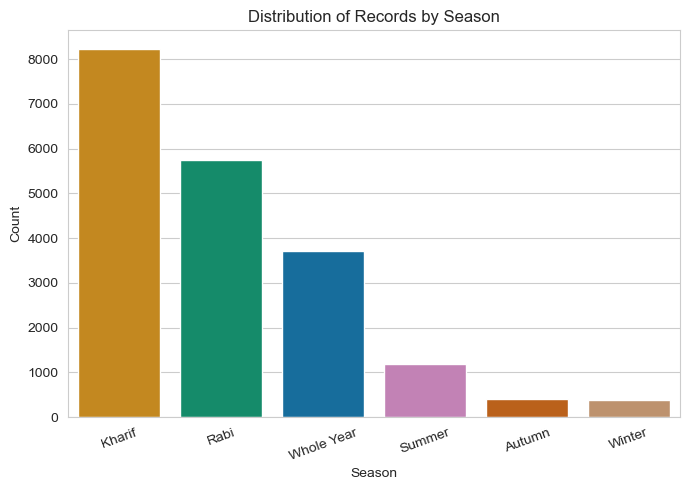

In [5]:
# Categorical distribution: Season
plt.figure(figsize=(7, 5))
season_order = df["Season"].value_counts().index
sns.countplot(data=df, x="Season", order=season_order, hue="Season",
              palette="colorblind", legend=False)
plt.title("Distribution of Records by Season")
plt.xlabel("Season")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("season_countplot.png", bbox_inches="tight", dpi=100)
plt.show()

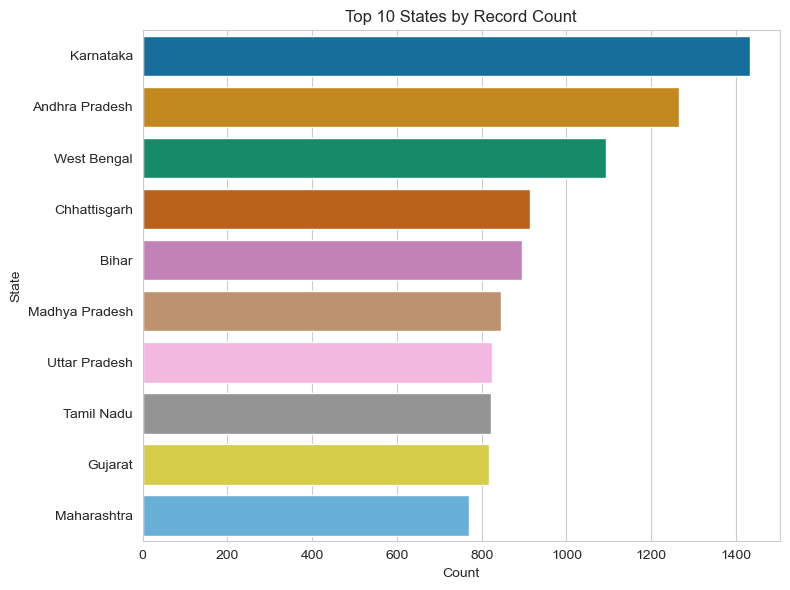

In [6]:
# Top 10 States by number of records
plt.figure(figsize=(8, 6))
top_states = df["State"].value_counts().head(10)
sns.barplot(x=top_states.values, y=top_states.index, hue=top_states.index,
            palette="colorblind", legend=False)
plt.title("Top 10 States by Record Count")
plt.xlabel("Count")
plt.ylabel("State")
plt.tight_layout()
plt.savefig("top_states.png", bbox_inches="tight", dpi=100)
plt.show()

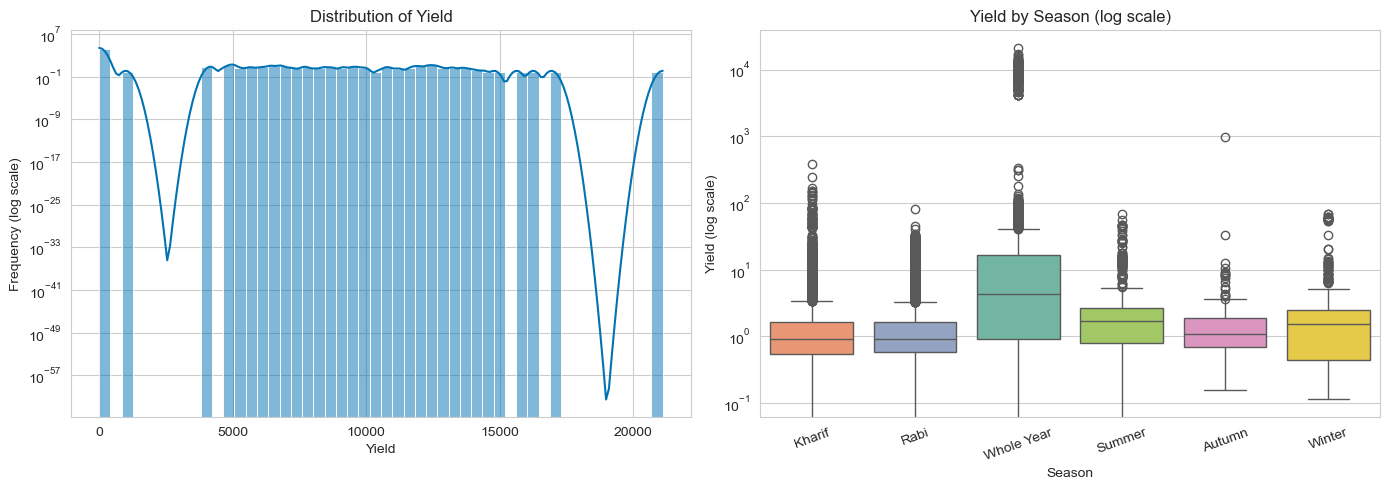

In [7]:
# Target distribution + Yield by Season
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["Yield"], kde=True, ax=axes[0], bins=50)
axes[0].set_title("Distribution of Yield")
axes[0].set_xlabel("Yield")
axes[0].set_yscale("log")
axes[0].set_ylabel("Frequency (log scale)")

sns.boxplot(data=df, x="Season", y="Yield", order=season_order, hue="Season",
            palette="Set2", legend=False, ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Yield by Season (log scale)")
axes[1].set_xlabel("Season")
axes[1].set_ylabel("Yield (log scale)")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig("target_distribution1.png", bbox_inches="tight", dpi=100)
plt.show()

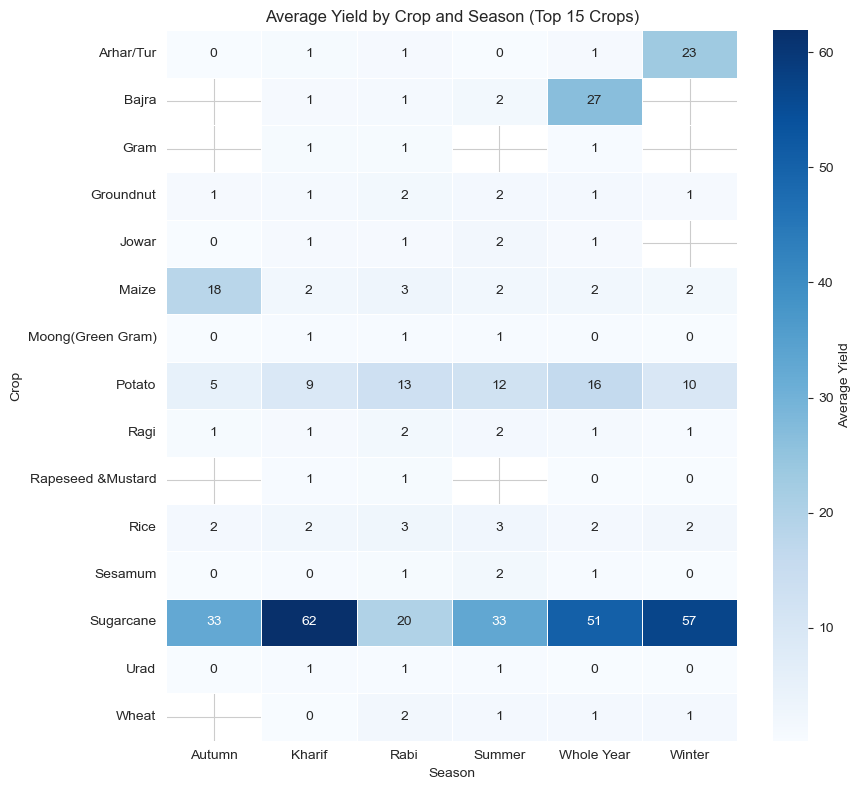

In [8]:
# Heatmap: Average Yield by Crop and Season (Blues colormap)
top_crops = df["Crop"].value_counts().head(15).index
pivot_crop_season = df[df["Crop"].isin(top_crops)].pivot_table(
    values="Yield", index="Crop", columns="Season", aggfunc="mean"
)

plt.figure(figsize=(9, 8))
sns.heatmap(pivot_crop_season, annot=True, fmt=".0f", cmap="Blues", linewidths=0.5,
            cbar_kws={"label": "Average Yield"})
plt.title("Average Yield by Crop and Season (Top 15 Crops)")
plt.xlabel("Season")
plt.ylabel("Crop")
plt.tight_layout()
plt.savefig("crop_season_yield_heatmap.png", bbox_inches="tight", dpi=100)
plt.show()

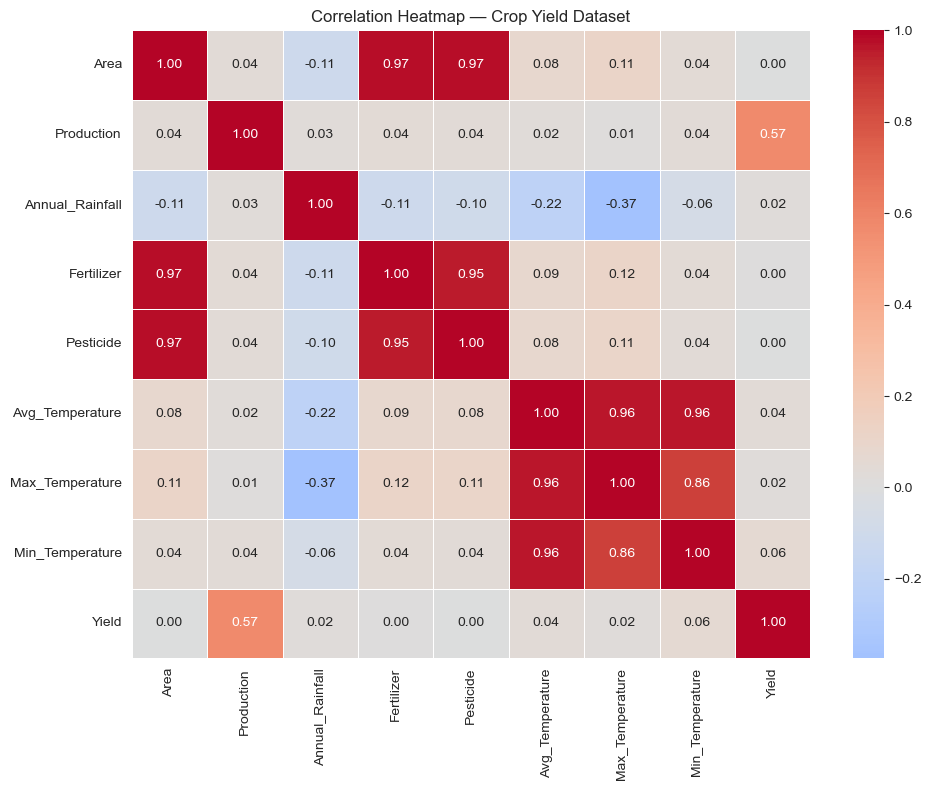

In [9]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
corr_cols = numeric_cols + ["Yield"]
corr = df[corr_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, linewidths=0.5, fmt=".2f")
plt.title("Correlation Heatmap — Crop Yield Dataset")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", bbox_inches="tight", dpi=100)
plt.show()

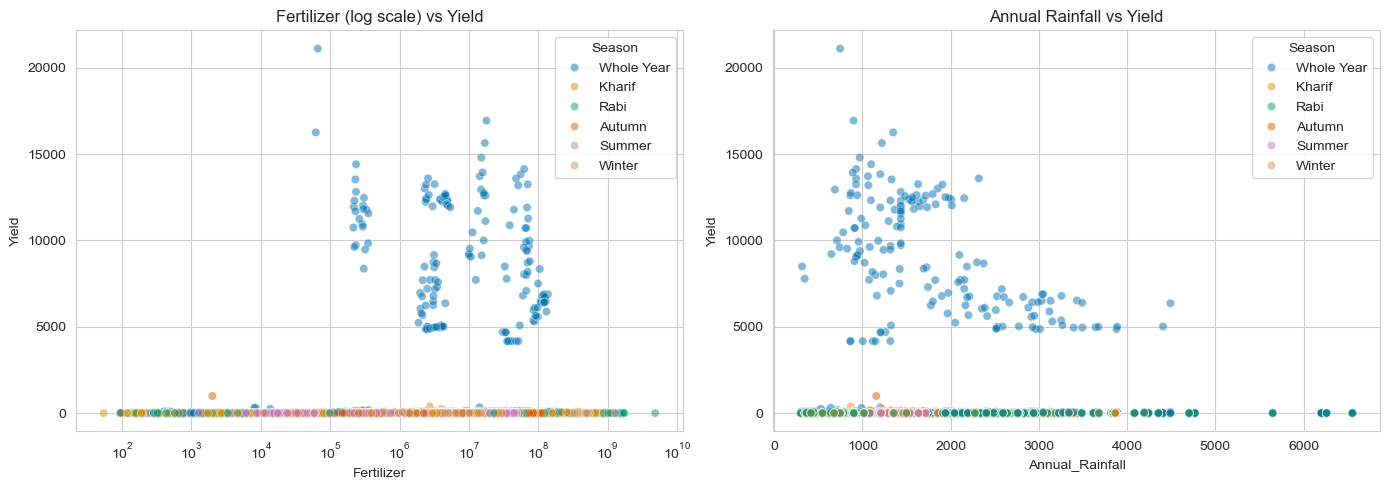

In [10]:
# Scatter plots: feature vs target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x="Fertilizer", y="Yield", hue="Season", alpha=0.5, ax=axes[0])
axes[0].set_xscale("log")
axes[0].set_title("Fertilizer (log scale) vs Yield")

sns.scatterplot(data=df, x="Annual_Rainfall", y="Yield", hue="Season", alpha=0.5, ax=axes[1])
axes[1].set_title("Annual Rainfall vs Yield")

plt.tight_layout()
plt.savefig("scatter_feature_target.png", bbox_inches="tight", dpi=100)
plt.show()

### A3. Insight commentary

**Observation:**

- **Target distribution**: `Yield` is strongly right-skewed — most crop-season-state records cluster
  at low yield values, with a long tail from a handful of high-yield crops measured in different units.
- **Feature distributions**: `Area`, `Production`, `Fertilizer`, and `Pesticide` are all heavily
  right-skewed, dominated by a small number of large-farm / high-volume records.
- **Season distribution**: Kharif and Rabi dominate the record count; Autumn and Winter are rare,
  so a stratified split on `Season` is used in Section B to keep this balance consistent across
  train/test.
- **Feature vs target**: No single numeric feature shows a strong linear trend against `Yield` on
  its own — yield is driven more by *which* crop/season/state a record belongs to than by any one
  numeric driver, which is why the categorical features are retained (not dropped) for modelling.